# Chapitre 4.2 - Les fichiers CSV, JSON et les requêtes

---

## Le format JSON


*Dit : Jayzone à l'Américaine ou gisson à la française*

### 1. Historique 

Le format JSON est apparu pendant la première moitié des années 2000 et a été développé pour alléger la communication de données "simples" sur le web. Il est né dans le contexte du langage JavaScript mais est aujourd'hui utilisé dans l'ensemble des langages fortement utilisés (python, java, ruby, php, etc.)

Le JSON est aujourd'hui présent dans 99% des requêtes du web sans que vous vous en rendiez compte ! Il est en effet le format privilégié par les développeurs pour communiquer entre le client et le serveur une fois la page affichée. 

### 2. Structure
    Si je regarde la communication entre Twitter et mon client, je peux voir quelque chose comme cela dans les ce qui est communiqué de mon navigateur (*Note: * pour respecter la vie privée du professeur, ce qui est affiché en dessous et le résultat d'une recherche sur l'API de Twitter pour les termes "Humanités Numériques"):

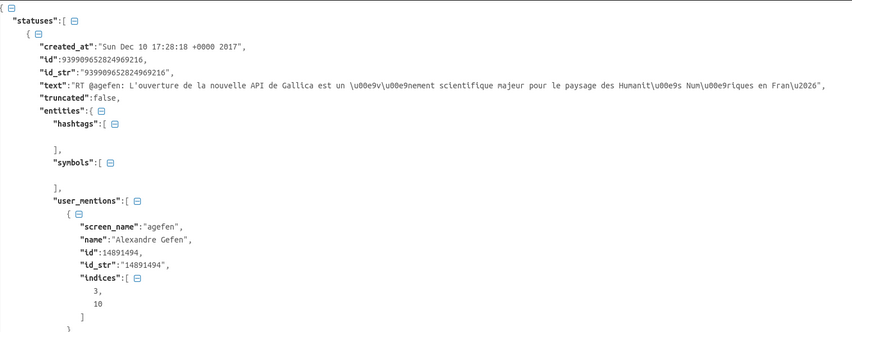

Vous reconnaissez ? JSON est en fait très proche de la manière de décrire des dictionnaires ou des listes en python. Et de fait, l'objet racine de JSON peut être une liste ou un dictionnaire et peut contenir :
- des listes,
- des dictionnaires,
- des booléens,
- des chaines de caractères
- des entiers et des décimaux
- des objets "vides" (`null`, l'équivalent de `None` en Python)

Voici un exemple simple en commençant par une liste comme élément source:

```json
[
    {"vers": 1, "texte": "Après l'insurrection du 17 juin,"},
    {"vers": 2, "texte": "Le secrétaire de l'Union des Écrivains"},
    {"vers": 3, "texte": "Fit distribuer des tracts dans la Stalinallée."},
    {"vers": 4, "texte": "Le peuple, y lisait-on, a par sa faute"},
    {"vers": 5, "texte": "Perdu la confiance du gouvernement"},
    {"vers": 6, "texte": "Et ce n'est qu'en redoublant d'efforts"},
    {"vers": 7, "texte": "Qu'il peut la regagner."},
    {"vers": 8, "texte": "Ne serait-il pas"},
    {"vers": 9, "texte": "Plus simple alors pour le gouvernement"},
    {"vers": 10, "texte": "De dissoudre le peuple"},
    {"vers": 11, "texte": "Et d'en élire un autre ?"}
]
```

et un exemple en commençant par un dictionnaire : 

```json
{
    "titre": {"fre": "La Solution", "ger": "Die Lösung"},
    "auteur": "Bertold Brecht",
    "annee": 1953,
    "source": "https://fr.wikipedia.org/wiki/Die_L%C3%B6sung",
    "vers": [
        {"n": 1, "texte": "Après l'insurrection du 17 juin,"},
        {"n": 2, "texte": "Le secrétaire de l'Union des Écrivains"},
        {"n": 3, "texte": "Fit distribuer des tracts dans la Stalinallée."},
        {"n": 4, "texte": "Le peuple, y lisait-on, a par sa faute"},
        {"n": 5, "texte": "Perdu la confiance du gouvernement"},
        {"n": 6, "texte": "Et ce n'est qu'en redoublant d'efforts"},
        {"n": 7, "texte": "Qu'il peut la regagner."},
        {"n": 8, "texte": "Ne serait-il pas"},
        {"n": 9, "texte": "Plus simple alors pour le gouvernement"},
        {"n": 10, "texte": "De dissoudre le peuple"},
        {"n": 11, "texte": "Et d'en élire un autre ?"}
    ]
}
```

### 3. JSON et Python

Tout comme pour `csv`, Python propose son propre module. Le module [`json`](https://docs.python.org/3.5/library/json.html). Et tout comme pour `csv`, il propose un outil pour lire et un pour écrire !

#### a. Lire

Python propose deux fonctions pour lire du JSON : `json.load()` et `json.loads()`. La différence entre les deux est très ténue : la première prend une instance de fichier en cours de lecture, l'autre une chaine de caractère (d'où le `s` à la fin pour `str`):

In [3]:
import json

# A partir d'un wrapper de fichier
with open("data/json/brecht.json") as f:
    print(json.load(f))
    
# A partir d'une chaîne
with open("data/json/brecht.json") as f:
    chaine = f.read()
    print(json.loads(chaine))

{'titre': {'fre': 'La Solution', 'ger': 'Die LÃ¶sung'}, 'auteur': 'Bertold Brecht', 'annee': 1953, 'source': 'https://fr.wikipedia.org/wiki/Die_L%C3%B6sung', 'vers': [{'n': 1, 'texte': "AprÃ¨s l'insurrection du 17 juin,"}, {'n': 2, 'texte': "Le secrÃ©taire de l'Union des Ã‰crivains"}, {'n': 3, 'texte': 'Fit distribuer des tracts dans la StalinallÃ©e.'}, {'n': 4, 'texte': 'Le peuple, y lisait-on, a par sa faute'}, {'n': 5, 'texte': 'Perdu la confiance du gouvernement'}, {'n': 6, 'texte': "Et ce n'est qu'en redoublant d'efforts"}, {'n': 7, 'texte': "Qu'il peut la regagner."}, {'n': 8, 'texte': 'Ne serait-il pas'}, {'n': 9, 'texte': 'Plus simple alors pour le gouvernement'}, {'n': 10, 'texte': 'De dissoudre le peuple'}, {'n': 11, 'texte': "Et d'en Ã©lire un autre ?"}]}
{'titre': {'fre': 'La Solution', 'ger': 'Die LÃ¶sung'}, 'auteur': 'Bertold Brecht', 'annee': 1953, 'source': 'https://fr.wikipedia.org/wiki/Die_L%C3%B6sung', 'vers': [{'n': 1, 'texte': "AprÃ¨s l'insurrection du 17 juin,"}, 

Puisque ces structures sont connues de Python, elles sont traduites par Python dans les structures équivalentes ! On peut désormais s'amuser avec les données :

In [4]:
import json

# A partir d'un wrapper de fichier
with open("data/json/brecht.json") as f:
    poeme = json.load(f)
    
print(poeme["titre"]["fre"])
print("-- " + poeme["auteur"])
for line in poeme["vers"]:
    print("({0}) {1}".format(line["n"], line["texte"]))

La Solution
-- Bertold Brecht
(1) AprÃ¨s l'insurrection du 17 juin,
(2) Le secrÃ©taire de l'Union des Ã‰crivains
(3) Fit distribuer des tracts dans la StalinallÃ©e.
(4) Le peuple, y lisait-on, a par sa faute
(5) Perdu la confiance du gouvernement
(6) Et ce n'est qu'en redoublant d'efforts
(7) Qu'il peut la regagner.
(8) Ne serait-il pas
(9) Plus simple alors pour le gouvernement
(10) De dissoudre le peuple
(11) Et d'en Ã©lire un autre ?


#### b. comme bonus : la méthode `.format()` pour la concaténation de chaine

La concaténation de chaines peut vite devenir ennuyeuse, répétitive, fautive. Heureusement, python propose des outils plutôt bien pensés pour gérer la concaténation de manière plus claire : la méthode `format`.

`.format()` est appelé sur une chaine et remplace à l'intérieur de cette chaine les valeurs entre accolades. Par défaut, elle remplace les accolades dans l'ordre des variables :


In [5]:
"{} est en premiere position, {} en deuxieme".format(1, 2)

'1 est en premiere position, 2 en deuxieme'

On remarque que Python gère le *casting* des nombres en chaine lui-même ici. Le code ci-dessus peut-être encore plus clarifié en l'écrivant ainsi :

In [6]:
"{0} est en premiere position, {1} en deuxieme, et {0} était bien le premier".format(1, 2)

'1 est en premiere position, 2 en deuxieme, et 1 était bien le premier'

Quand on traite de grandes chaines, on peut simplifier encore : il s'agit alors de nommer des noms à ses remplacements :

In [7]:
# L'indentation n'est pas obligatoire. Mais elle rend le code plus lisible
"{nom} a écrit le poème '{titre}'. {nom} est {nationalite}.".format(
    nom="Brecht", titre="Solution", nationalite="allemand"
)

"Brecht a écrit le poème 'Solution'. Brecht est allemand."

#### c. Écrire

Tout comme pour la lecture, le module JSON propose deux fonctions pour l'écriture qui correspondent à l'écriture dans une chaine de caractère (`json.dumps()`) ou dans un fichier (`dump`):

In [8]:
import json

mon_objet = [
    {
        "titre": "Hacking Websites with SQL Injection - Computerphile",
        "lien" : "https://www.youtube.com/watch?v=_jKylhJtPmI"
    },
    {
        "titre": "Cross Site Request Forgery - Computerphile",
        "lien": "https://www.youtube.com/watch?v=vRBihr41JTo"
    }
]

In [9]:
# Avec une chaîne de caractère comme objectif
chaine_json = json.dumps(mon_objet)
print(chaine_json)
print(type(chaine_json))

[{"titre": "Hacking Websites with SQL Injection - Computerphile", "lien": "https://www.youtube.com/watch?v=_jKylhJtPmI"}, {"titre": "Cross Site Request Forgery - Computerphile", "lien": "https://www.youtube.com/watch?v=vRBihr41JTo"}]
<class 'str'>


In [11]:
# Avec un fichier commme objectif
with open("data/json/youtube.exemple.json", "w") as f:
    json.dump(mon_objet, f)
    
# On vérifie que cela marche bien :
with open("data/json/youtube.exemple.json") as f:
    chaine = f.read()
    objet_recharge = json.loads(chaine)
    print(objet_recharge[0]["titre"])

Hacking Websites with SQL Injection - Computerphile


#### d. Exercice

Le fichier [data/json/twitter.humanitesnumeriques.json](data/json/twitter.humanitesnumeriques.json) contient quelques tweets comprenant la mention "humanites numeriques". 

1. Lisez le fichier (*utilisez si nécessaire un formateur comme [JSON Formatter](https://jsonformatter.curiousconcept.com/)*)
2. Essayez de comprendre la structure
3. Afficher grâce à une boucle les tweets en suivant l'exemple suivant :

```
http://twitter.com/statuses/939909652824969216    lapointejm    RT @agefen: L'ouverture de la nouvelle API de Gallica est un événement scientifique majeur pour le paysage des Humanités Numériques en Fran…
```

In [12]:
# Votre code ici

#### e. Exercice supplémentaire

À partir du code précédent, transformez l'exercice en chargeant le même fichier JSON et en écrivant un fichier CSV reprenant la structure en colonne `Lien | Auteur | Date | Tweet`

In [ ]:
# Votre code ici

----

#### Ce que l'on a appris

Pour finir cette section, voici un récapitulatif des concepts appris. Lisez la liste et posez des questions si certaines choses ne sont pas claires.

- La structure d'un fichier json
- `json.load`
- `json.loads`
- `json.dump`
- `json.dumps`
- `from ___ import ___`
- la notion de librairie/module/package
- `csv.reader()`
- `csv.writer()`
- `enumerate()`
- Lire une documentation et ses exemples

#### Ce que l'on recommande d'approfondir

Si les fonctions `csv.reader()` et `csv.writer()` sont sympathiques, les fonctions `DictReader` et `DictWriter` le sont beaucoup plus : elles stockent les noms de colonnes ! *cf.* [la documentation](https://docs.python.org/3.5/library/csv.html#csv.DictReader)